<a href="https://colab.research.google.com/github/maytediaz0226-debug/M-todos-num-ricos-2-/blob/main/Regla_CompuestaSimpson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="font-family: 'Georgia';font-size:18px;">
METODOS NUMERICOS II. Regla compuesta de Simpson
</div>




**INTRODUCCION**

La **Regla compuesta de Simpson** es un metodo numerico utilizado para aproximar el valor de una integral definida cuando obtener una solucion exacta puede resultar dificil o cuando se necesita el calculo de una integral mediante valores conocidos de una funcion.

Se basa en aproximar la funcion mediante pequeños subintervalos del intervalo de integracion. El intervalo $[a,b]$ se divide en un numero par de subintervalos de igual longitud donde **h** es $$h=\frac{b-a}{n}$$
con  **n** un numero par.

Si se tienen los puntos $x_i=a+ih,\qquad i=0,1,2\ldots,n$
aproxima la integral $\in\int_a^b f(x),dx$

$$
\int_a^b f(x)dx\approx\frac{h}{3}\left[f(x_0)+4\sum_{\substack{i=1\text{ impar}}}^{n-1}f(x_i)+2\sum_{\substack{i=2\text{ par}}}^{n-2}f(x_i)+f(x_n)\right]$$

mediante la expresion

$$\int_a^b f(x)dx\approx\frac{h}{3}\left[f(x_0)+4f(x_1)+2f(x_2)+4f(x_3)+\cdots+2f(x_{x-2})+4f(x_{n-1})+f(x_n)\right]$$

Para aplicar el metodo primero se determinara el numero de subintervalos $n$, este debe ser par, despues se calcula el tamaño de cada subintervalo mendiante $$h=\frac{b-a}{n}$$
despues se obtienen los puntos de evaluacion mendiante $$x_i=a+ih$$
y se evalua en cada uno. Finalmente estos valores se sustituyen en la fromula de Simpson asignando a los coeficientes de acuerdo con la posicion de cada punto

**OBJETIVO**


Implementar en lenguaje Phyton la **Regla compuesta de Simpson** correspondiente a el algoritmo 4.1 del Burden

Ejercicio 1. Determine los valores de $n$ y $h$ para aproximar

$$\int_0^2 e^{2x}\sin(3x)\,dx$$
con un error menor que $$10^{-4}$$

Se desea aproximar
$$ I= \int_0^2 e^{2x}\sin(3x),dx$$
Para aplicar la regla compuesta de Simpson utilizando la formula
$$ \approx\frac{h}{3}\left[f(a)+4\sum_{\substack{i=1\\i\text{impar}}}^{n-1}f(x_i)+2\sum_{\substack{i=2\\i\text{par}}}^{n-2}f(x_i)+f(b)\right],$$
donde
$$x_i=a+ih$$
y $$h=\frac{b-a}{n}$$

Tenemos que $$a=0\qquad b=2$$ por lo que $$ h=\frac{2}{n}$$

Para determinar el numero de subintervalos necesitamos utilizar el termino de error de la **Regla compuesta de Simpson**

El error esta dado por
$$ E(f) =\frac{b-a}{180}h^4f^{(4)}(\mu)$$
para algun $\mu\in(a,b)$


Por lo tanto, podemos utilizar la cota
$$|E(f)|\leq\frac{b-a}{180}h^4\max_{a\leq x\leq b}| f^{(4)}(x)|$$

Tenemos $$f(x)=e^{2x}\sin(3x)$$

Calculando derivadas

$$ f^{(4)}(x)= -e^{2x}\left(119\sin(3x)+120\cos(3x)\right)$$
Por lo tanto
$$|f^{(4)}(x)|=e^{2x}|119\sin(3x)+120\cos(3x)|$$

Utilizando $$|A\sin(\theta)+B\cos(\theta)|\leq\sqrt{A^2+B^2}$$
obtenemos
$$|119\sin(3x)+120\cos(3x)|\leq\sqrt{119^2+120^2}=169$$

entonces
$$|f^{(4)}(x)|\leq 169e^{2x}$$

en el intervalo $[0,2]$

$$e^{2x}\leq e^4$$

Por lo tanto, podemos utilizar la cota $$M=169e^4$$




Queremos que $$|E(f)|<10^{-4}$$
Utilizando la cota del error
$$|E(f)|\leq\frac{b-a}{180}h^4M$$

Sustituyendo los valores
$$ a=0, \qquad b=2 \qquad M=169e^4$$
tenemos

$$|E(f)|\leq\frac{2}{180}h^4(169e^4)$$

$$\frac{2}{180}h^4(169e^4)\leq10^{-4}$$

$$h^4\leq\frac{180(10^{-4})}{2(169e^4)}$$

$$h\leq\left(\frac{180(10^{-4})}{2(169e^4)}\right)^{1/4}$$

Se obtiene aproximadamente $$h\leq 0.0314264$$







como $$h=\frac{b-a}{n}=\frac{2}{n}$$

tenemos $$\frac{2}{n}\leq0.0314264$$

$$n\geq63.6408$$

Como la Regla compuesta de Simpson require que $n$ sea **par**, tomamos el siguiente entero par $n=64$

finalmente $$ h=\frac{2-0}{64}$$

$$\boxed{h=0.03125}$$

In [27]:
import math
a=0
b=2

error=10**(-4) #error
M=169*math.exp(4)
h_max=((180*error)/((b-a)*M))**(1/4)
n_min=(b-a)/h_max
n=math.ceil(n_min)

if n%2 !=0:
  n=n+1

h=(b-a)/n

print("Cota maxima para h=",h_max)
print("valor minimo de n=",n_min)
print("n=", n)
print("h=", h)

Cota maxima para h= 0.03142638808433131
valor minimo de n= 63.64078476448165
n= 64
h= 0.03125


**Implementando el Algoritmo 4.1 del Burden**

Se utilizan tres acumuladores


$XI0$: contiene $f(a)+f(b)$


$XI1$: acumula los valores correspondientes a indices impares


$XI2$: acumula los valores correspondientes a indices pares

Finalmente se utiliza
$$XI=\frac{h}{3}(XI0+4XI1+2XI2)$$

In [28]:
def simp(f,a,b,n):
  if n%2 !=0:
    raise ValueError("n debe ser par")

    h=(b-a)/n
    XI0=f(a)+f(b)
    XI1=0
    XI2=0

    for i in range(1,n):
      X=a+i*h
      if i%2==0:
        XI2=XI2+f(X)
      else:
        XI1=XI1+f(X)

    XI=h/3*(XI0+4*XI1+2*XI2)
    return XI


In [29]:
def f(x):
  return math.exp(2*x)*math.sin(3*x)

  a=0
  b=2
  n=64

  resultado=simp(f,a,b,n)
  print("resultado:")
  print(resultado)

In [30]:
def simpson(f,a,b,n):
  h=(b-a)/n

  XI0=f(a)+f(b)
  XI1=0
  XI2=0

  print("h=",h)
  print()
  print("i       x_i.        f(x_i)")

  for i in range(1,n):
    X=a+i*h
    print(f"{i:2d}     {X:.8f}")
    if i%2==0:
      XI2=XI2 +f(X)
    else:
      XI1=XI1+f(X)

    XI=(h/3)*(XI0+4*XI1+2*XI2)
    print()
    print("XI0=", XI0)
    print("XI1=", XI1)
    print("XI2=", XI2)
    print("Resultado=", XI)

    return XI
    resultado= simpson(f,a,b,n)


La cota teorica del error es

$$ |E(f)|\leq \frac {b-a}{180}h^4M$$

con $$ n=64\qquad h=0.03125\qquad M=169e^4$$

se obtiene
$$|E(f)|\leq\frac{2}{180}(0.03125)^4(169e^4)$$

por lo tanto $$|E(f)|\leq 9.7774\times10^{-5}$$

como $$ 9.7774\times10^{-5}<10^{-4}$$

se cumple la condicion solicitada

In [31]:
error_cota=((b-a)/180)*(h**4)*M
print("cota del error =", error_cota)
print("error maximo permitido=", error)

if error_cota < error:
  print("la condicion se cumple")
else:
    print("no se cumple la condicion")

cota del error = 9.777373584748772e-05
error maximo permitido= 0.0001
la condicion se cumple


Grafica de $f(x)=e^{x^2}\sin(3x)$

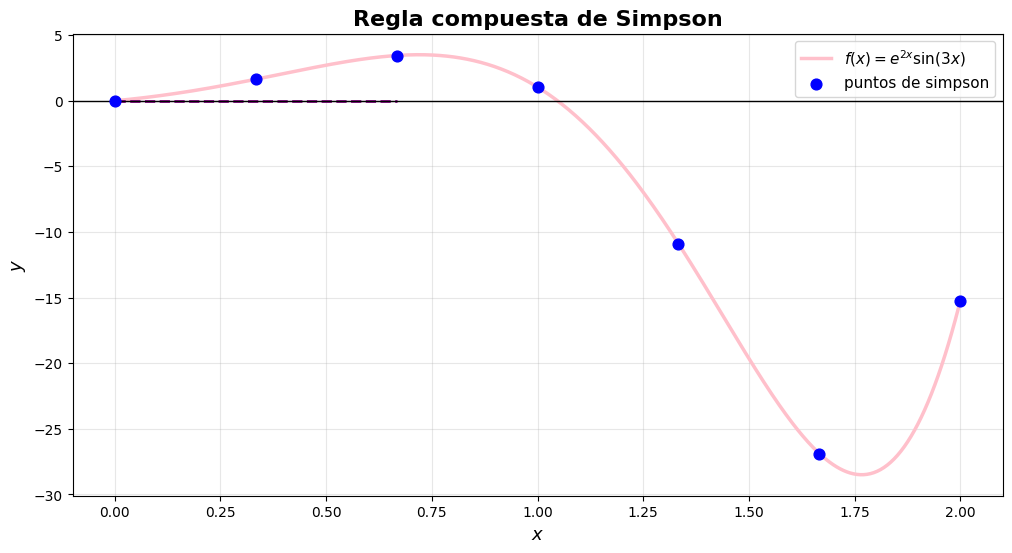

/tmp/ipykernel_2426/816490361.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=11)


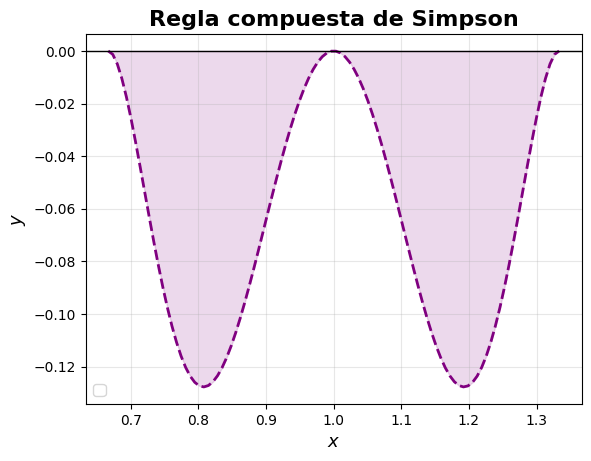

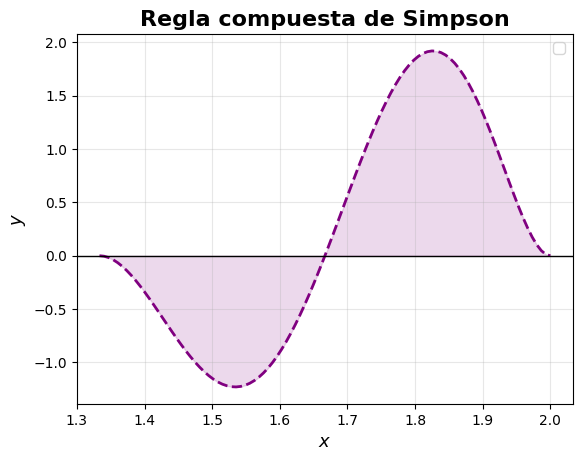

In [32]:
import numpy as np
import matplotlib.pyplot as plt
def f(x):
  return np.exp(2*x)* np.sin(3*x)

a=0
b=2
n=6
h=(b-a)/n

x= np.linspace(a,b,n+1)
y=f(x)
xx=np.linspace(a,b,500)

plt.figure(figsize=(12,6))
plt.plot(xx,f(xx), color='pink', linewidth=2.5, label=r'$f(x)=e^{2x}\sin(3x)$')

plt.scatter(x,y, color='blue', s=60, zorder=5, label='puntos de simpson')

for i in range (0,n,2):

  x0=x[i]
  x1=x[i+1]
  x2=x[i+2]

  y0=y[i]
  y1=y[i+1]
  y2=y[i+2]

  xp= np.linspace(x0,x2,100)
  p=(y0*((xp-1)*(xp-x2))/((x0-x1)*(x0-x2))*((xp-x0)*(xp-x2))/((x1-x0)*(x1-x2))*((xp-x0)*(xp-x1))/((x2-x0)*(x2-x1)))
  plt.plot(xp,p, color= 'purple', linewidth=2, linestyle='--')
  plt.fill_between(xp,p,0, color='purple', alpha=0.15)
  plt.axhline(0, color='black', linewidth=1)

  plt.title('Regla compuesta de Simpson', fontsize=16, fontweight='bold')

  plt.xlabel('$x$', fontsize=13)
  plt.ylabel('$y$', fontsize=13)

  plt.legend(fontsize=11)
  plt.grid(alpha=0.3)

  plt.show()

**CONCLUSION Y RESULTADOS**

Para aproximar $$\int_0^2 e^{2x}\sin(3x)\,dx$$

con un error menor que $10^{-4}$ mediante la **Regla compuesta de Simpson**, se obtuvieron los siguientes valores

$$\boxed{n=64}$$

y

$$\boxed{h=0.03125}$$

La aproximación obtenida mediante el **Algoritmo 4.1** fue de

$$\boxed{\int_0^2 e^{2x}\sin(3x)\,dx\approx -14.21397094}$$

La cota teórica del error es

$$|E(f)|\leq9.7774\times10^{-5}$$

y como

$$
9.7774\times10^{-5}<10^{-4},
$$ se cumple la precisión solicitada

Por lo tanto, los valores requeridos para la Regla compuesta de Simpson son

$$\boxed{n=64,\qquad h=0.03125}$$

y la aproximación de la integral es

$$\boxed{-14.21397094}$$